# Test complex-grid `build_t_app_G_app`

This notebook tests `t_complex_interpolation_workflow.build_t_app_G_app` on a rectangular complex `t` tube. It filters the tube grid to points where SCE or WCE is accurate within `epsilon`, then compares the returned `G_app` values against the exact solution at the same filtered points.


In [12]:
import sys
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt

from t_complex_interpolation_workflow import (
    compute_exact_t,
    build_t_app_G_app,
)


In [13]:
# Parameter setup.
beta = 10.0
Ns = 2
Nw = 4 * int(beta)
Mat_fre = (2 * np.linspace(0, Nw - 1, Nw) + 1) * np.pi / beta
wn = np.append(-np.flip(Mat_fre), Mat_fre)

U = 8.0
T = 20.0
sce_order = 8
wce_order = 8
epsilon = 1e-3

# Select one Matsubara frequency for this test.
n_fit = Nw - 1
print("selected Matsubara index:", n_fit)
print("selected omega:", wn[n_fit])


selected Matsubara index: 39
selected omega: -0.3141592653589793


In [14]:
# Rectangular complex tube grid.
tube_delta = 1.0
tube_real_window = (-T, T)
N_real_lattice = 501
N_imag_lattice = 101


def make_tube_lattice(real_window, delta, n_real, n_imag):
    lo, hi = real_window
    real_axis = np.linspace(lo, hi, n_real)
    imag_axis = np.linspace(-delta, delta, n_imag)
    real_grid, imag_grid = np.meshgrid(real_axis, imag_axis)
    t_grid = real_grid + 1j * imag_grid
    return real_grid, imag_grid, t_grid


def tube_boundary(real_window, delta):
    lo, hi = real_window
    return np.array([
        lo - 1j * delta,
        hi - 1j * delta,
        hi + 1j * delta,
        lo + 1j * delta,
        lo - 1j * delta,
    ])


def lattice_field_from_points(t_points, values, real_grid, imag_grid):
    field = np.full(real_grid.shape, np.nan, dtype=float)
    real_axis = real_grid[0]
    imag_axis = imag_grid[:, 0]
    real_step = real_axis[1] - real_axis[0]
    imag_step = imag_axis[1] - imag_axis[0]

    real_idx = np.rint((t_points.real - real_axis[0]) / real_step).astype(int)
    imag_idx = np.rint((t_points.imag - imag_axis[0]) / imag_step).astype(int)
    field[imag_idx, real_idx] = values
    return field


real_grid, imag_grid, t_grid = make_tube_lattice(
    tube_real_window,
    tube_delta,
    N_real_lattice,
    N_imag_lattice,
)
t_values = t_grid.ravel()
boundary = tube_boundary(tube_real_window, tube_delta)

print("tube grid shape:", t_grid.shape)
print("total tube points:", t_values.size)


tube grid shape: (101, 501)
total tube points: 50601


In [15]:
# Exact baseline on the whole complex tube grid for the selected frequency.
G_exact_all = compute_exact_t(t_values, np.array([wn[n_fit]]), U, beta)[:, 0]
print("G_exact_all shape:", G_exact_all.shape)


G_exact_all shape: (50601, 2, 2)


In [16]:
# Build filtered approximation data on the complex grid.
t_app, G_app = build_t_app_G_app(
    sce_order=sce_order,
    wce_order=wce_order,
    baseline_G=G_exact_all,
    t_values=t_values,
    epsilon=epsilon,
    wn=wn[n_fit],
    U=U,
    beta=beta,
)

G_exact_app = compute_exact_t(t_app, np.array([wn[n_fit]]), U, beta)[:, 0]
err_app = np.max(np.abs(G_app - G_exact_app), axis=(1, 2))

print("t_app shape:", t_app.shape)
print("G_app shape:", G_app.shape)
print("max filtered error:", np.max(err_app) if err_app.size else np.nan)
print("mean filtered error:", np.mean(err_app) if err_app.size else np.nan)
print("epsilon:", epsilon)


Selected complex t points: 41361 of 50601 | SCE valid: 457 | WCE valid: 40904
t_app shape: (41361,)
G_app shape: (41361, 2, 2)
max filtered error: 0.0009986177199501245
mean filtered error: 2.6891270336206766e-05
epsilon: 0.001


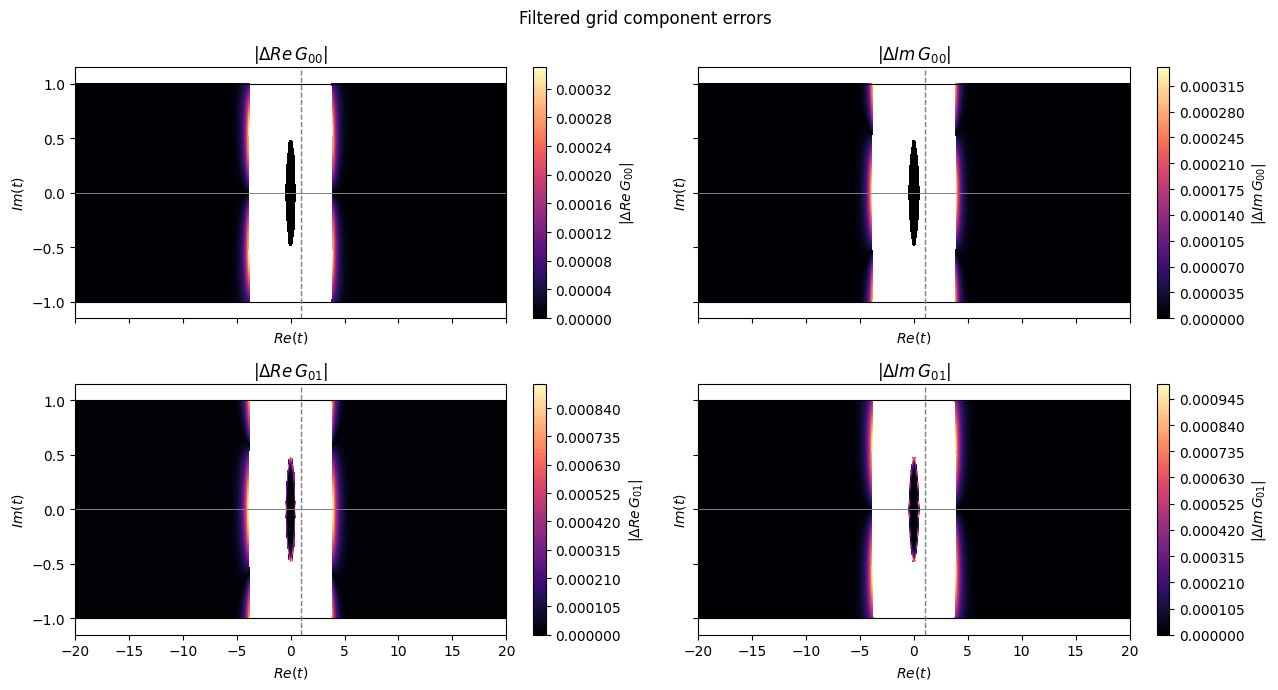

In [17]:
# Error distribution over the filtered complex tube points for selected components.
error_components = [
    (0, 0, np.real, r"$|\Delta Re\,G_{00}|$"),
    (0, 0, np.imag, r"$|\Delta Im\,G_{00}|$"),
    (0, 1, np.real, r"$|\Delta Re\,G_{01}|$"),
    (0, 1, np.imag, r"$|\Delta Im\,G_{01}|$"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True, sharey=True)
for ax, (i, j, part, title) in zip(axes.ravel(), error_components):
    values = np.abs(part(G_app[:, i, j]) - part(G_exact_app[:, i, j]))
    field = lattice_field_from_points(t_app, values, real_grid, imag_grid)
    cf = ax.contourf(real_grid, imag_grid, field, levels=80, cmap="magma")
    ax.plot(boundary.real, boundary.imag, color="k", linewidth=0.8)
    ax.axhline(0, color="0.5", linewidth=0.7)
    ax.axvline(1, color="gray", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(r"$Re(t)$")
    ax.set_ylabel(r"$Im(t)$")
    ax.set_ylim(-1.15 * tube_delta, 1.15 * tube_delta)
    fig.colorbar(cf, ax=ax, label=title)

fig.suptitle(r"Filtered grid component errors")
fig.tight_layout()
plt.show()


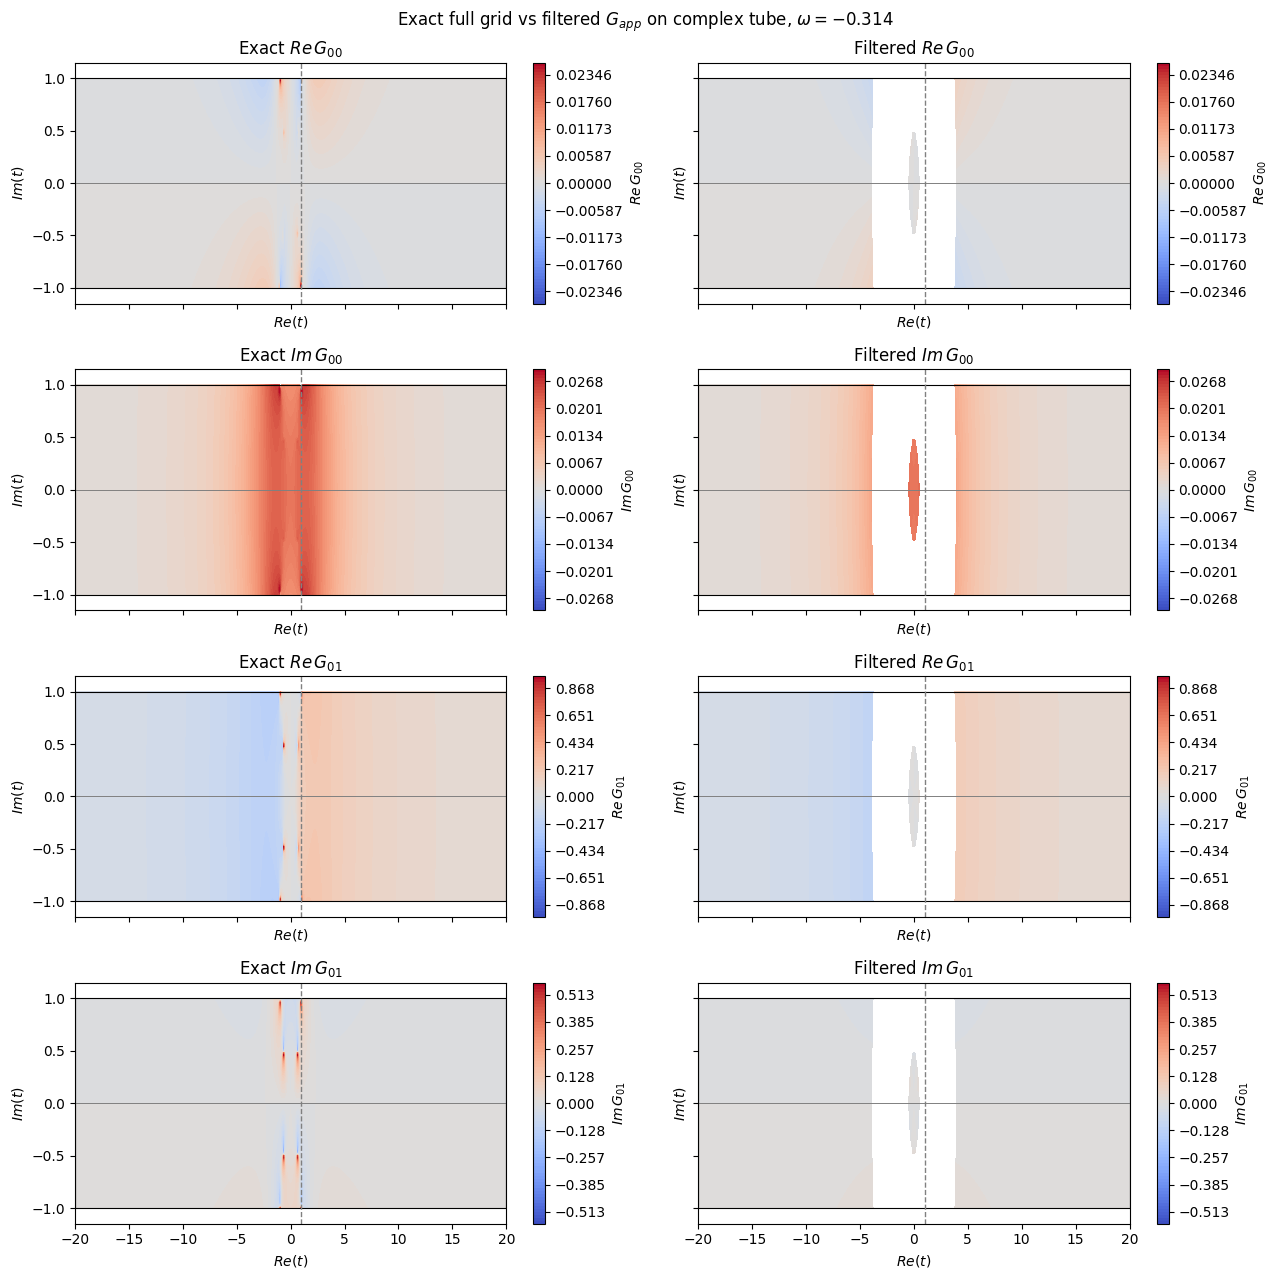

In [18]:
# Exact versus filtered approximation on the complex tube grid.
# The exact panels use all tube-grid points; the filtered panels use only t_app.
comparison_components = [
    (0, 0, np.real, r"$Re\,G_{00}$"),
    (0, 0, np.imag, r"$Im\,G_{00}$"),
    (0, 1, np.real, r"$Re\,G_{01}$"),
    (0, 1, np.imag, r"$Im\,G_{01}$"),
]

fig, axes = plt.subplots(4, 2, figsize=(13, 13), sharex=True, sharey=True)
for row, (i, j, part, title) in enumerate(comparison_components):
    exact_values_all = part(G_exact_all[:, i, j])
    app_values = part(G_app[:, i, j])

    exact_field = exact_values_all.reshape(real_grid.shape)
    app_field = lattice_field_from_points(t_app, app_values, real_grid, imag_grid)

    vmax = np.nanmax(np.abs([exact_field, app_field]))
    levels = np.linspace(-vmax, vmax, 81) if vmax > 0 else 80

    panels = [
        (exact_field, "Exact " + title),
        (app_field, "Filtered " + title),
    ]
    for col, (field, panel_title) in enumerate(panels):
        ax = axes[row, col]
        cf = ax.contourf(real_grid, imag_grid, field, levels=levels, cmap="coolwarm")
        ax.plot(boundary.real, boundary.imag, color="k", linewidth=0.8)
        ax.axhline(0, color="0.5", linewidth=0.7)
        ax.axvline(1, color="gray", linestyle="--", linewidth=1)
        ax.set_title(panel_title)
        ax.set_xlabel(r"$Re(t)$")
        ax.set_ylabel(r"$Im(t)$")
        ax.set_ylim(-1.15 * tube_delta, 1.15 * tube_delta)
        fig.colorbar(cf, ax=ax, label=title)

fig.suptitle(rf"Exact full grid vs filtered $G_{{app}}$ on complex tube, $\omega={wn[n_fit]:.3g}$")
fig.tight_layout()
plt.show()


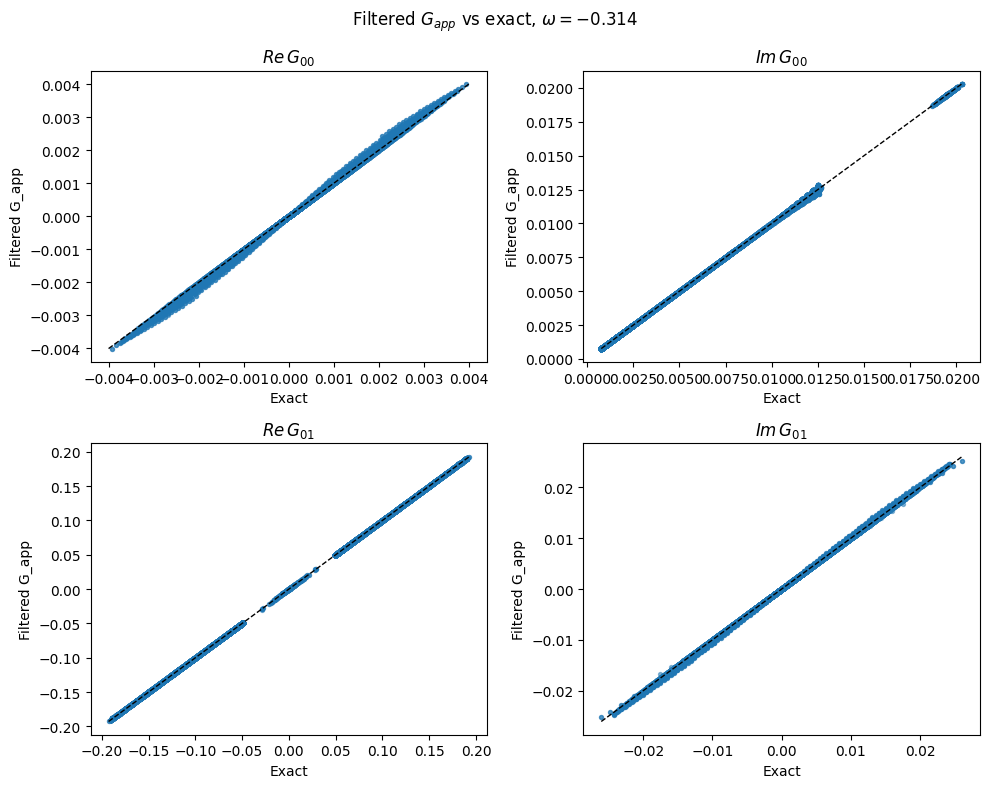

In [19]:
# Compare exact and filtered approximation values for selected components.
components = [
    (0, 0, np.real, r"$Re\,G_{00}$"),
    (0, 0, np.imag, r"$Im\,G_{00}$"),
    (0, 1, np.real, r"$Re\,G_{01}$"),
    (0, 1, np.imag, r"$Im\,G_{01}$"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (i, j, part, title) in zip(axes.ravel(), components):
    exact_values = part(G_exact_app[:, i, j])
    app_values = part(G_app[:, i, j])
    ax.scatter(exact_values, app_values, s=8, alpha=0.5)
    lo = np.nanmin([np.nanmin(exact_values), np.nanmin(app_values)])
    hi = np.nanmax([np.nanmax(exact_values), np.nanmax(app_values)])
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Exact")
    ax.set_ylabel("Filtered G_app")

fig.suptitle(rf"Filtered $G_{{app}}$ vs exact, $\omega={wn[n_fit]:.3g}$")
fig.tight_layout()
plt.show()


/var/folders/yy/fy66fl5x6jjfygf6_125n2dh0000gp/T/ipykernel_24971/3290773476.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


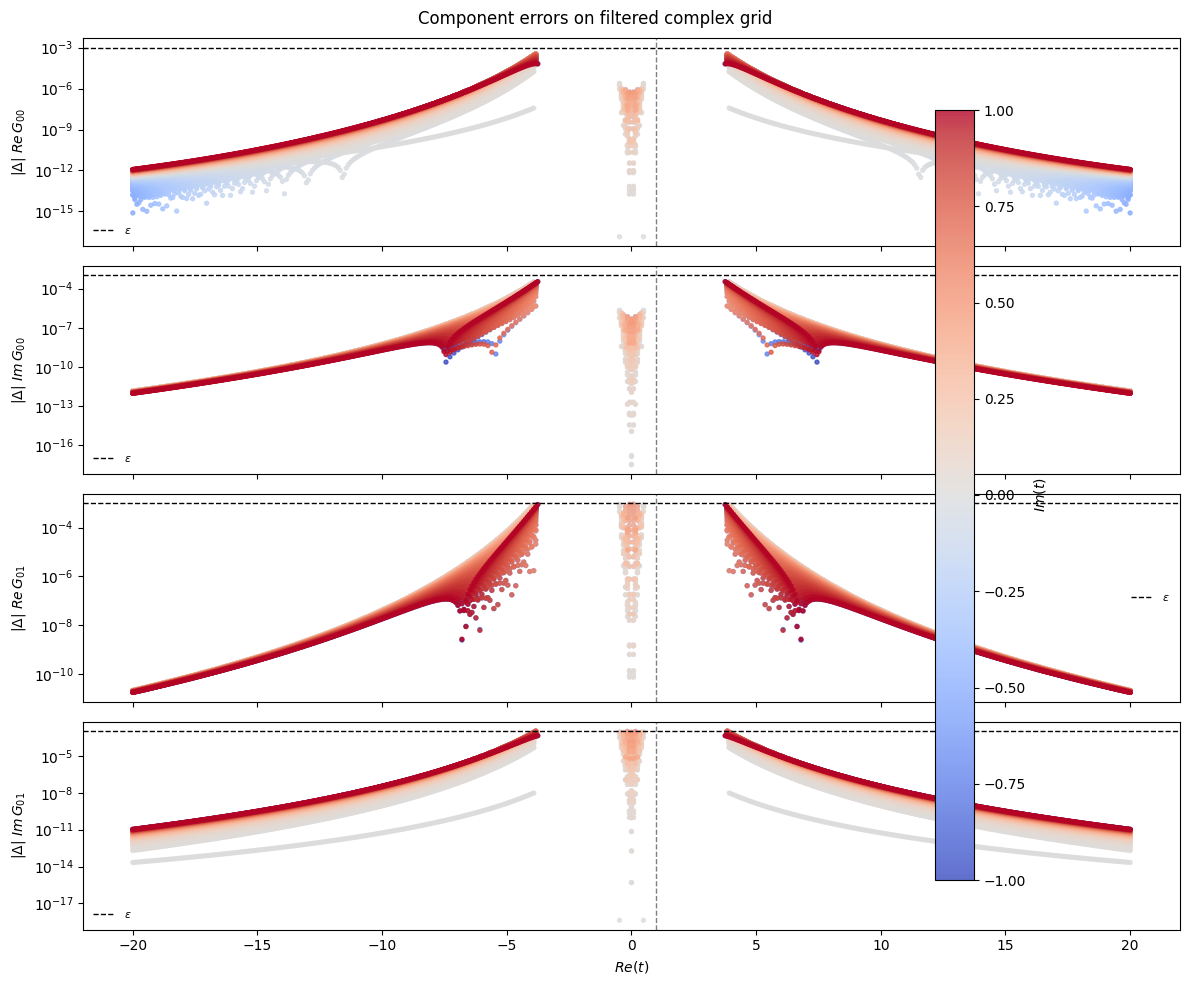

In [20]:
# Component-wise error along Re(t), with color indicating Im(t).
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
for ax, (i, j, part, title) in zip(axes, components):
    values = np.abs(part(G_app[:, i, j]) - part(G_exact_app[:, i, j]))
    sc = ax.scatter(t_app.real, values, c=t_app.imag, s=8, cmap="coolwarm", alpha=0.8)
    ax.axhline(epsilon, color="k", linestyle="--", linewidth=1, label=r"$\epsilon$")
    ax.axvline(1, color="gray", linestyle="--", linewidth=1)
    ax.set_yscale("log")
    ax.set_ylabel(r"$|\Delta|$ " + title)
    ax.legend(frameon=False, fontsize=8)

axes[-1].set_xlabel(r"$Re(t)$")
fig.colorbar(sc, ax=axes, label=r"$Im(t)$")
fig.suptitle(r"Component errors on filtered complex grid")
fig.tight_layout()
plt.show()
